# 语音指令识别

In [1]:
!pip install tensorflow seaborn librosa torchaudio==0.6.0 vad

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.6/479.6 MB 2.4 MB/s eta 0:00:0000:0100:05
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 3.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 3.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 2.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 3.0 MB/s

In [2]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility. 设置实验可重复性的种子值。
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

2024-05-09 01:54:19.570047: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-09 01:54:19.572894: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-09 01:54:19.623581: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-09 01:54:19.624360: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-09 01:54:20.509865: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

## 导入数据集

[数据集](https://tensorflow.google.cn/datasets/catalog/speech_commands)包含超过 105,000 个音频文件，采用 <a href="https://www.aelius.com/njh/wavemetatools/doc/riffmci.pdf" class="external">WAV（波形）音频文件格式</a>，内容是不同的人们说出 35 个不同的单词。此数据由 Google 收集并根据 CC BY 许可发布。
<center class="half">
    <img src="notebook/Speech_Commands1.png" width="300"/><br>
    <img src="notebook/Speech_Commands2.png" width="300"/>
</center>
<br>
数据集采集环境：所有语音片段都是通过手机或笔记本电脑的麦克风在用户所处的各种环境下采集的用以实现设备端触发短语任务的音频。<br><br>
数据：为了简化训练和评估过程，我决定将所有语音片段的标准持续时间限制为一秒钟。这虽然排除了较长的单词，但由于关键词识别的常见目标通常是简短的词语，所以这一限制似乎并不过于严格。我还决定仅记录孤立说出的单个单词，而不是作为句子的一部分，因为这更接近我们所瞄准的触发词任务，并且由于对齐不是关键因素，这也使得标注工作变得更加简单。

In [3]:
DATASET_PATH = 'data/command_ness'

data_dir = pathlib.Path(DATASET_PATH)

读取文件的名称（所需要的指令）

In [4]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
print('Commands:', commands)

Commands: ['down' 'happy' 'left' 'right' 'up']


以这种方式划分目录，您可以使用 `keras.utils.audio_dataset_from_directory` 轻松加载数据。

音频剪辑在 16kHz 时为 1 秒或更短。`output_sequence_length=16000` 会将短音频剪辑填充到恰好 1 秒（并且会**修剪较长的音频剪辑**），以便可以轻松地对它们进行批处理。

In [5]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2, #设置训练集与验证集的比例，总数据集的20%用于验证集，80%用于训练集。
    seed=0, #用于确保每次执行时数据集划分的一致性
    output_sequence_length=16000, #每段音频都会被截断或填充到16000个采样点
    subset='both') #同时生成训练集和验证集

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 11196 files belonging to 5 classes.
Using 8957 files for training.
Using 2239 files for validation.

label names: ['down' 'happy' 'left' 'right' 'up']


2024-05-09 01:54:21.877556: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


数据集现在包含批量的音频剪辑和整数标签。音频剪辑的形状为 `(batch, samples, channels)`。

In [6]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

此数据集仅包含**单声道音频**（不用管channels数据），因此使用 `tf.squeeze` 函数删除额外的轴：

In [7]:
def squeeze(audio, labels):
  print(audio.shape)
  audio = tf.squeeze(audio, axis=-1)
  print(audio.shape)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

(None, 16000, None)
(None, 16000)
(None, 16000, None)
(None, 16000)


`utils.audio_dataset_from_directory` 函数最多只返回两个拆分。将测试集与验证集分开是一个好主意。理想情况下，您会将其保存在单独的目录中，但在这种情况下，您可以使用 `Dataset.shard` 将验证集拆分成两半。请注意，遍历**任何**分片将加载**所有**数据，并且只保留它的片段。

分为测试数据集和验证数据集合，对数据进行更细致的分割，用于不同的实验或评估目的，或者确保在分布式训练中每个节点都获得不同但均衡的数据分布。

In [8]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [9]:
for example_audio, example_labels in train_ds.take(1): 
  print(example_audio.shape) #1st batch of train_ds
  print(example_labels.shape)

(64, 16000)
(64,)


绘制一些音频波形：

测试dtype="<U5"的格式

In [10]:
names=np.array(["苏三","离了","洪洞县","123456"],dtype="<U5") # dtype="U5"表示字符串不超过5位
print(names.dtype)

<U5


In [11]:
label_names[[1,2,3,4,0]]

array(['happy', 'left', 'right', 'up', 'down'], dtype='<U5')

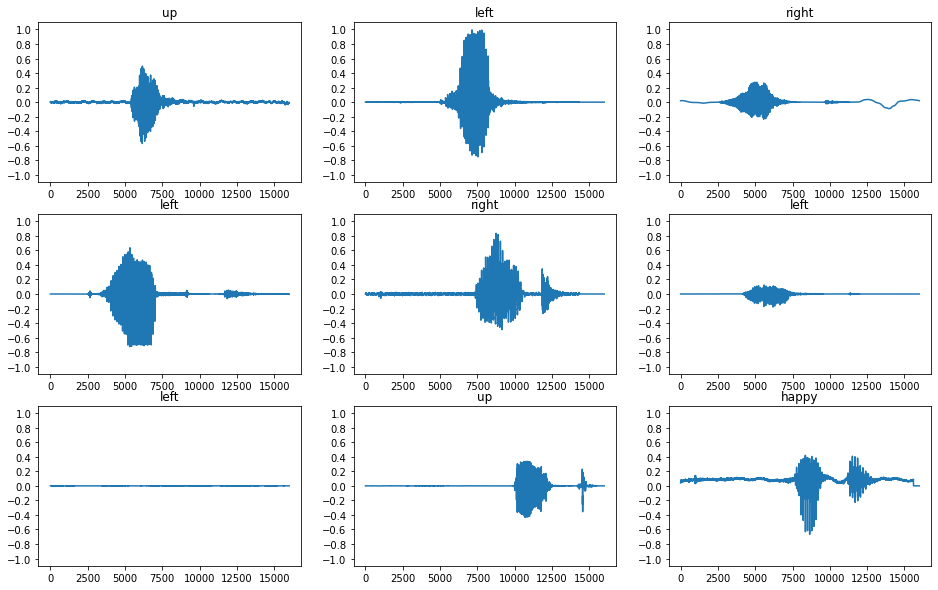

In [12]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[2 * i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[2 * i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

## 将波形转换为频谱图

数据集中的波形在时域中表示。接下来，您将通过计算<a href="https://en.wikipedia.org/wiki/Short-time_Fourier_transform" class="external">短时傅里叶变换 (STFT)</a> 将波形从时域信号转换为时频域信号，以将波形转换为<a href="https://en.wikipedia.org/wiki/Spectrogram" clas="external">频谱图</a>，显示频率随时间的变化，并且可以表示为二维图像。您将把频谱图图像输入您的神经网络以训练模型。

傅里叶变换 (`tf.signal.fft`) 会将信号转换为其分量频率，但会丢失所有时间信息。相比之下，STFT (`tf.signal.stft`) 会将信号拆分为时间窗口，并在每个窗口上运行傅里叶变换，保留一些时间信息，并返回可以运行标准卷积的二维张量。

创建用于将波形转换为频谱图的效用函数：

- 这些波形需要具有相同的长度，以便将它们转换为频谱图时，结果具有相似的维度。这可以通过简单地对短于一秒的音频片段进行零填充（使用 `tf.zeros`）来完成。
- 调用 `tf.signal.stft` 时，请选择 `frame_length` 和 `frame_step` 参数，使生成的频谱图“图像”几乎为方形。有关 STFT 参数选择的更多信息，请参阅有关音频信号处理和 STFT 的 <a href="https://www.coursera.org/lecture/audio-signal-processing/stft-2-tjEQe" class="external">Coursera 视频</a>。
- STFT 会产生表示幅度和相位的复数数组。但是，在本教程中，您将只使用幅度，您可以通过在 tf.signal.stft 的输出上应用 `tf.abs` 来获得该 `tf.signal.stft`。

In [13]:
def get_spectrogram(waveform):
  '''将波形信号转换为声谱图'''
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  #waveform: 输入的音频波形数据
  #frame_length: 每次提取一个片段进行傅里叶变换的点数
  #frame_step: 相邻窗口之间的时间间隔
  spectrogram = tf.abs(spectrogram)
  #计算STFT后的复数结果的绝对值，得到幅度谱反映了各个频率分量随时间变化的强度
  spectrogram = spectrogram[..., tf.newaxis]
  #由于大多数深度学习框架在处理图像等数据时期望的数据维度格式为 
  #(batch_size, height, width, channels)，所以添加一个额外的维度来表示
  #通道（channels）。这里通过[..., tf.newaxis]操作给声谱图增加了一个维度，
  #使其形状符合深度学习模型对输入的要求。
  return spectrogram

接下来，开始探索数据。打印一个样本的张量波形形状和相应的频谱图，并播放原始音频：

In [14]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: up
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: right
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: left
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


现在，定义一个显示频谱图的函数：

In [15]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
    #删减维度以适应二维图像显示的需求
  #将声谱图进行对数变换和转置。对数变换可以更好地展示信号强度的变化范围，
  #同时使得高频部分与低频部分在视觉上更均衡。通过加上一个很小的正数（如
  #浮点数类型最小正数np.finfo(float).eps）来避免对零值取对数（因为对数的定义域不包括零）。
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  #print(height)
  width = log_spec.shape[1]
  #print(width)
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

绘制样本随时间变化的波形和相应的频谱图（随时间变化的频率）：

/tmp/ipykernel_17937/2272446363.py:16: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(X, Y, log_spec)


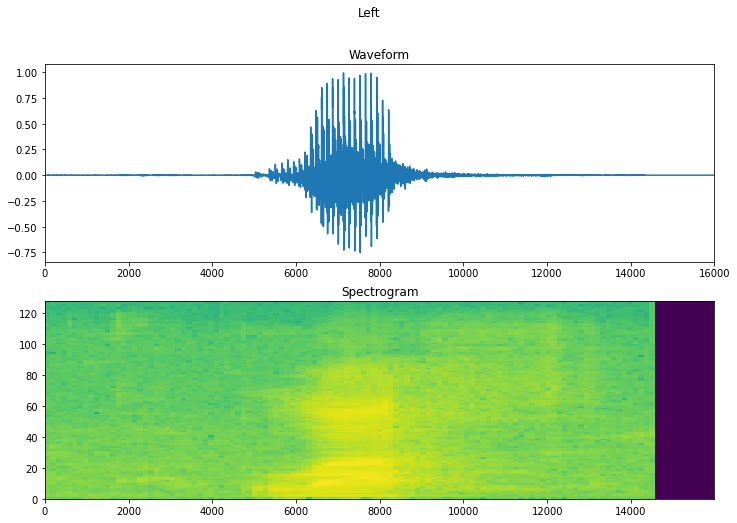

In [16]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

接下来，从音频数据集创建频谱图数据集：

In [17]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [18]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

检查数据集不同样本的频谱图：

In [19]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

/tmp/ipykernel_17937/2272446363.py:16: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(X, Y, log_spec)


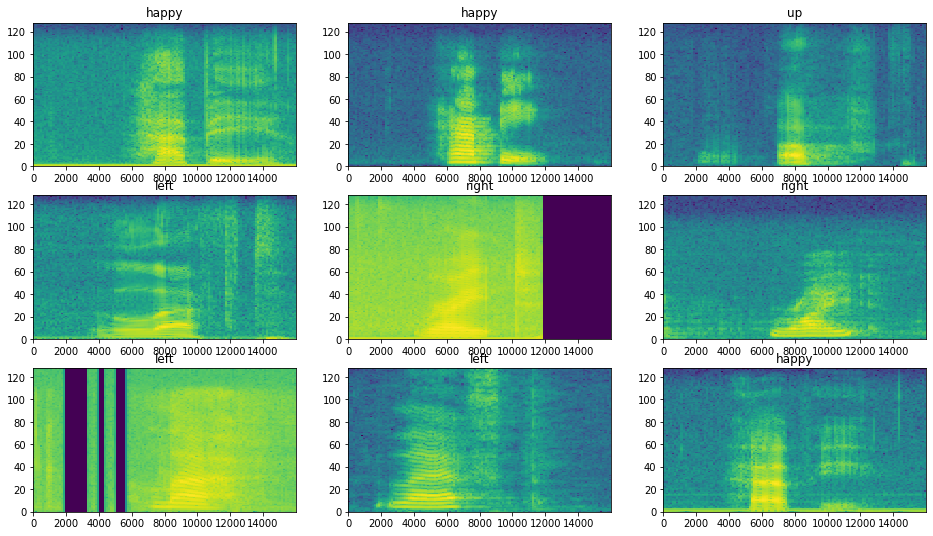

In [20]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])
    
plt.show()

## 构建并训练模型

添加 `Dataset.cache` 和 `Dataset.prefetch` 运算以减少训练模型时的读取延迟：

In [21]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

对于模型，您将使用简单的卷积神经网络 (CNN)，因为您已将音频文件转换为频谱图图像。

您的 `tf.keras.Sequential` 模型将使用以下 Keras 预处理层：

- `tf.keras.layers.Resizing`：对输入进行下采样以使模型训练得更快。
- `tf.keras.layers.Normalization`：根据图像的均值和标准差对图像中的每个像素进行归一化。

对于 `Normalization` 层，首先需要在训练数据上调用其 `adapt` 方法，以计算聚合统计数据（即均值和标准差）。

In [22]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)
print('num_labels:', num_labels)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
print(layers)
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)
num_labels: 5
<module 'keras.api._v2.keras.layers' from '/root/miniconda3/lib/python3.8/site-packages/keras/api/_v2/keras/layers/__init__.py'>
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 1)         0         
                                                                 
 normalization (Normalizati  (None, 32, 32, 1)         3         
 on)                                                             
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 64)        0         
 D)               

使用 Adam 优化器和交叉熵损失配置 Keras 模型：
Adam优化器（Adaptive Moment Estimation）是一种在训练神经网络时广泛使用的自适应学习率梯度下降算法。

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'], #定义评估指标
)

In [24]:
EPOCHS = 20
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=2),
    #在损失不再改善（连续patience次验证周期没有提升）的情况下提前停止训练过程，防止过拟合
    #verbose=1表示显示详细的日志信息
)

Epoch 1/20
140/140 [==============================] - 9s 57ms/step - loss: 1.1216 - accuracy: 0.5894 - val_loss: 0.5775 - val_accuracy: 0.8502
Epoch 2/20
140/140 [==============================] - 5s 37ms/step - loss: 0.5077 - accuracy: 0.8380 - val_loss: 0.3234 - val_accuracy: 0.9081
Epoch 3/20
140/140 [==============================] - 5s 38ms/step - loss: 0.3356 - accuracy: 0.8895 - val_loss: 0.2624 - val_accuracy: 0.9053
Epoch 4/20
140/140 [==============================] - 5s 37ms/step - loss: 0.2471 - accuracy: 0.9215 - val_loss: 0.2192 - val_accuracy: 0.9200
Epoch 5/20
140/140 [==============================] - 5s 38ms/step - loss: 0.1999 - accuracy: 0.9340 - val_loss: 0.1739 - val_accuracy: 0.9384
Epoch 6/20
140/140 [==============================] - 5s 37ms/step - loss: 0.1611 - accuracy: 0.9442 - val_loss: 0.1759 - val_accuracy: 0.9458
Epoch 7/20
140/140 [==============================] - 5s 37ms/step - loss: 0.1520 - accuracy: 0.9505 - val_loss: 0.1558 - val_accuracy: 0.9485

我们来绘制训练和验证损失曲线，以检查您的模型在训练期间的改进情况：

Text(0, 0.5, 'Accuracy [%]')

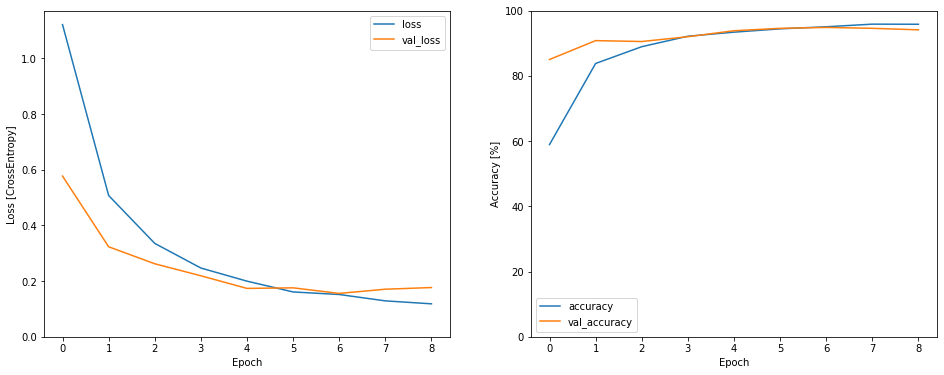

In [25]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## 评估模型性能

在测试集上运行模型并检查模型的性能：

In [26]:
model.evaluate(test_spectrogram_ds, return_dict=True)

18/18 [==============================] - 0s 15ms/step - loss: 0.1761 - accuracy: 0.9461


{'loss': 0.17611518502235413, 'accuracy': 0.9461337924003601}

### 显示混淆矩阵

使用<a href="https://developers.google.com/machine-learning/glossary#confusion-matrix" class="external">混淆矩阵</a>检查模型对测试集中每个命令的分类效果：


In [27]:
y_pred = model.predict(test_spectrogram_ds)
print(y_pred.shape)

18/18 [==============================] - 0s 5ms/step
(1151, 5)


In [28]:
y_pred = tf.argmax(y_pred, axis=1)
print(y_pred)

tf.Tensor([1 4 3 ... 4 4 1], shape=(1151,), dtype=int64)


In [29]:
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

<module 'seaborn' from '/root/miniconda3/lib/python3.8/site-packages/seaborn/__init__.py'>


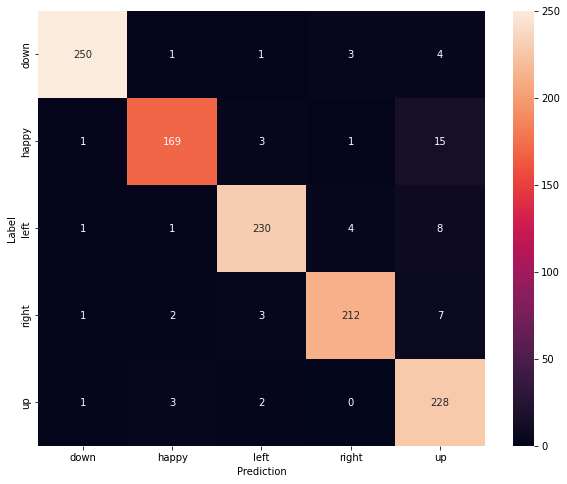

In [30]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
print(sns)
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

## 对音频文件运行推断


In [31]:
import librosa
import soundfile as sf

音频文件采样率转换

In [32]:
def resample_rate_test(path,new_sample_rate = 16000):
    signal, sr = librosa.load(path, sr=None)
    wavfile = path.split('/')[-1]
    wavfile = wavfile.split('.')[0]
    file_name = wavfile + '_new.wav'
    if sr is not None and sr != new_sample_rate:
        new_signal = librosa.resample(signal, orig_sr=sr, target_sr=new_sample_rate)
    sf.write('trans_test_data/' + file_name, new_signal, new_sample_rate)
    file_name = 'trans_test_data/' + file_name
    return file_name

音频起始点检测

<a href="vad_ex/energy_vad.py">EnergyVAD源文件</a>

In [33]:
#from vad import EnergyVAD
from vad_ex import EnergyVAD
import torchaudio
import torch

In [34]:
def Energy_waveform(path, voice_activity):
    audio, sample_rate = torchaudio.load(str(path))
    energy_waveform = []
    for i in range(len(voice_activity)):
        if voice_activity[i] == 1:
            energy_waveform.append(audio.numpy()[0, i * 320 : (i + 1) * 320])
    energy_waveform = np.concatenate(energy_waveform)
    # convert to tensor
    energy_waveform = torch.from_numpy(energy_waveform)
    energy_waveform = energy_waveform.unsqueeze(0)
    # save the new audio
    wavfile = path.split('/')[-1]
    wavfile = wavfile.split('.')[0]
    energy_waveform_path = 'energy_test_data/' + wavfile + '_Energy_new.wav'
    torchaudio.save(str(energy_waveform_path), energy_waveform, sample_rate)
    #print(energy_waveform_path)
    return energy_waveform, energy_waveform_path

In [35]:
def vadEnergy_audio(path, sample_rate=16000):
    audio, sample_rate = torchaudio.load(str(path))
    vad = EnergyVAD(
        sample_rate= sample_rate,
        frame_length= 25, # in milliseconds
        frame_shift= 20, # in milliseconds
        energy_threshold= 0.05, # you may need to adjust this value
        pre_emphasis= 0.95,
        ) # default values are used here
    voice_activity = vad(audio) # returns a boolean array indicating whether a frame is speech or not
    energy_waveform, energy_waveform_path = Energy_waveform(path, voice_activity)
    x = tf.audio.encode_wav(energy_waveform, sample_rate=16000, name=None)
    return voice_activity, energy_waveform, energy_waveform_path

展示一下修改频率的数据

## 这里定义音频路径

In [36]:
speech_signal_ori = 'test_data/up.wav'
audio_ori, rate_ori = torchaudio.load(str(speech_signal_ori))
print(f"original audio rate：", rate_ori)

audio_newRate = resample_rate_test(speech_signal_ori,new_sample_rate = 16000)
audio_newRate_path = str(audio_newRate)
audio_newRate, newRate = torchaudio.load(str(audio_newRate_path))
print(f"new rate：", newRate)

original audio rate： 48000
new rate： 16000


original audio:


vadEnergy audio:


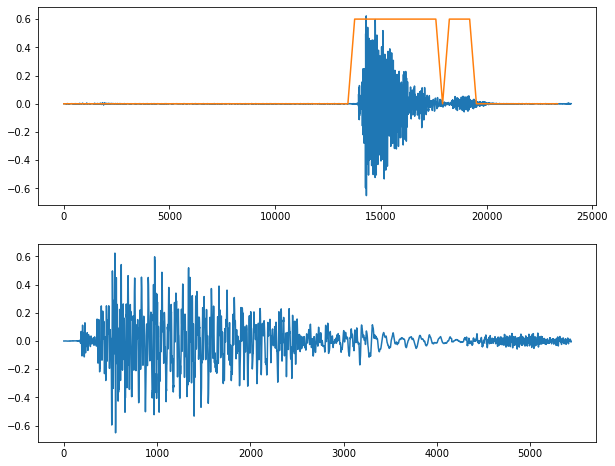

In [37]:
voice_activity, energy_waveform, energy_waveform_path = vadEnergy_audio(str(audio_newRate_path), sample_rate=newRate)
print('original audio:')
display.display(display.Audio(audio_newRate_path, rate=newRate))
print('vadEnergy audio:')
display.display(display.Audio(energy_waveform, rate=newRate))


fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(audio_newRate.numpy()[0, :])
axes[0].plot(np.arange(0, audio_newRate.shape[1], 320)[: len(voice_activity)], voice_activity * 0.6)

axes[1].plot(energy_waveform.numpy()[0, :])
plt.show()

In [38]:
wavfile = speech_signal_ori.split('/')[-1]
wavfile = wavfile.split('.')[0]

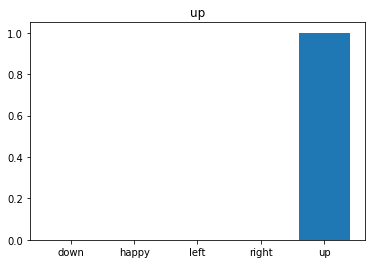

In [39]:
x = tf.io.read_file(str(energy_waveform_path))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)

x = tf.squeeze(x, axis=-1)

x = get_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = ['down', 'happy', 'left', 'right', 'up']
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title(str(wavfile))
plt.show()

display.display(display.Audio(waveform, rate=16000))

/tmp/ipykernel_17937/2272446363.py:16: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(X, Y, log_spec)


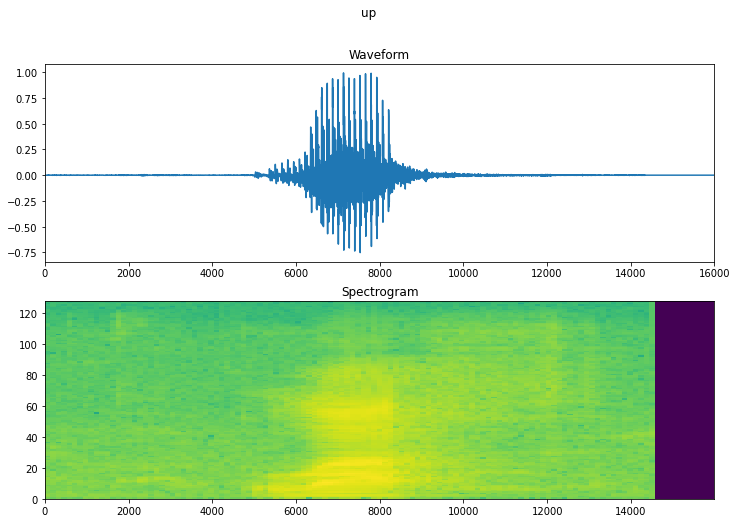

In [40]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
spectrogram = get_spectrogram(waveform)
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(str(wavfile))
plt.show()

## 通过预处理导出模型

如果您必须在将数据传递给模型进行推断之前应用这些预处理步骤，该模型不是很易于使用。因此，构建一个端到端的版本：

In [41]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    # Accept either a string-filename or a batch of waveforms.
    # YOu could add additional signatures for a single wave, or a ragged-batch.
    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string))
    self.__call__.get_concrete_function(
       x=tf.TensorSpec(shape=[None, 16000], dtype=tf.float32))


  @tf.function
  def __call__(self, x):
    # If they pass a string, load the file and decode it.
    if x.dtype == tf.string:
      x = tf.io.read_file(x)
      x, _ = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
      x = tf.squeeze(x, axis=-1)
      x = x[tf.newaxis, :]

    x = get_spectrogram(x)
    result = self.model(x, training=False)

    class_ids = tf.argmax(result, axis=-1)
    class_names = tf.gather(label_names, class_ids)
    return class_names

测试运行“导出”模型：

In [42]:
x = 'test_data/left.wav'
x = resample_rate_test(x,new_sample_rate = 16000)
voice_activity, energy_waveform, energy_waveform_path = vadEnergy_audio(str(x), sample_rate=16000)

export = ExportModel(model)
result = export(tf.constant(str(energy_waveform_path))).numpy()
result = result[0].decode('utf-8')

print('识别结果为', result)

识别结果为 left


保存并重新加载模型，重新加载的模型给出了相同的输出：

In [43]:
tf.saved_model.save(export, "saved")
imported = tf.saved_model.load("saved")
result = imported(waveform[tf.newaxis, :]).numpy()

INFO:tensorflow:Assets written to: saved/assets


INFO:tensorflow:Assets written to: saved/assets


In [44]:
result = result[0].decode('utf-8')
print('识别结果为', result)

识别结果为 left


In [45]:
result = 'left'

In [46]:
!python demos/demo_transfer.py --change_exp 'surprised' --change_pose 'left' --generate_frame 30

python: can't open file 'demos/demo_transfer.py': [Errno 2] No such file or directory
